In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv(r'C:\Users\Sande\Desktop\sales-trend-visualization\data\Walmart_Sales.csv')
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (6435, 8)

Columns:
 ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB
None

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Basic Stats:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.35

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Year_Month'] = df['Date'].dt.to_period('M')

print("Date columns added successfully!")
print(df[['Date', 'Year', 'Month', 'Month_Name']].head())

Date columns added successfully!
        Date  Year  Month Month_Name
0 2010-02-05  2010      2        Feb
1 2010-02-12  2010      2        Feb
2 2010-02-19  2010      2        Feb
3 2010-02-26  2010      2        Feb
4 2010-03-05  2010      3        Mar


In [5]:
import os
output_path = r'C:\Users\Sande\Desktop\sales-trend-visualization\output'
os.makedirs(output_path, exist_ok=True)
print("Output folder ready!")

Output folder ready!


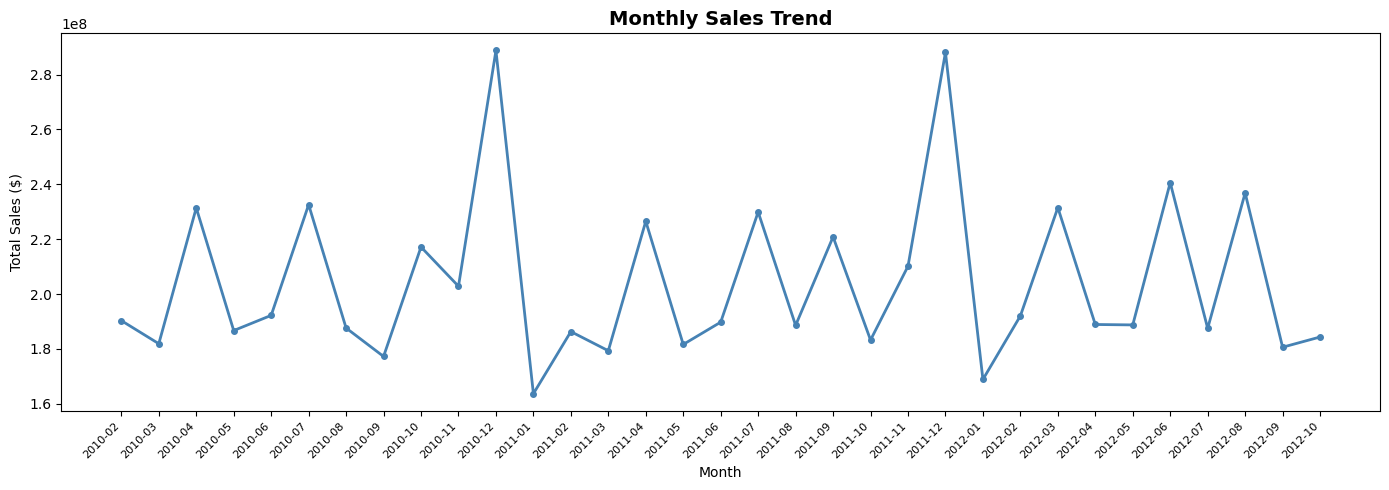

Chart saved!


In [6]:
monthly_sales = df.groupby('Year_Month')['Weekly_Sales'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Year_Month'], monthly_sales['Weekly_Sales'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\Users\Sande\Desktop\sales-trend-visualization\output\01_monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart saved!")

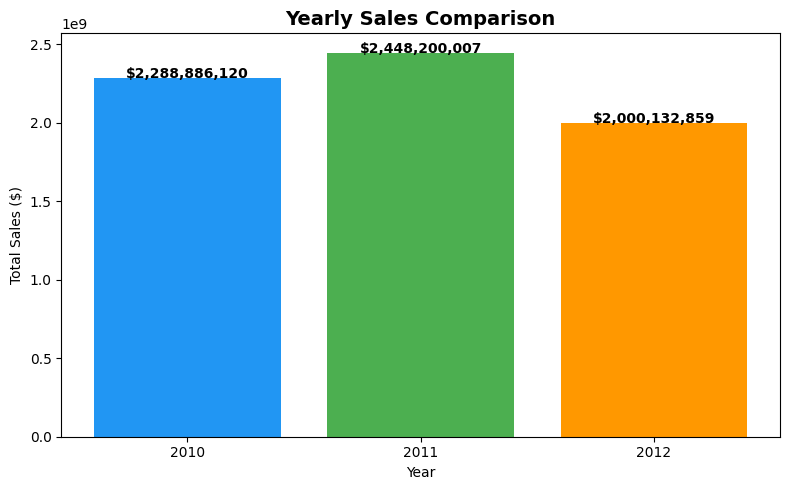

Chart saved!


In [7]:
yearly_sales = df.groupby('Year')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly_sales['Year'].astype(str), yearly_sales['Weekly_Sales'],
               color=['#2196F3','#4CAF50','#FF9800'])
plt.title('Yearly Sales Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')

for bar, val in zip(bars, yearly_sales['Weekly_Sales']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\Sande\Desktop\sales-trend-visualization\output\02_yearly_sales.png', dpi=150)
plt.show()
print("Chart saved!")

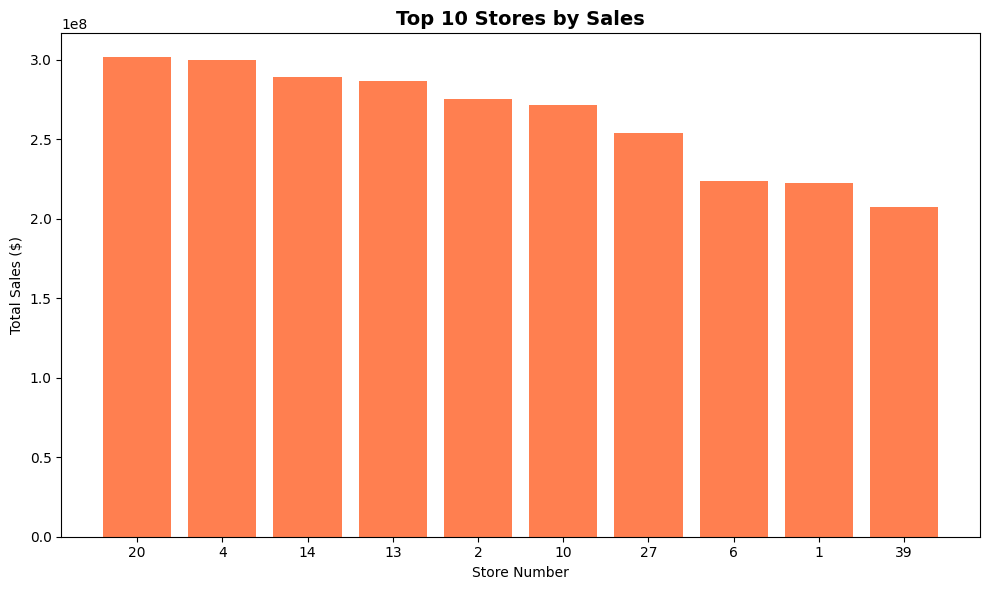

Chart saved!


In [8]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index().sort_values('Weekly_Sales', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(store_sales['Store'].astype(str), store_sales['Weekly_Sales'], color='coral')
plt.title('Top 10 Stores by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Store Number')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig(r'C:\Users\Sande\Desktop\sales-trend-visualization\output\03_top_stores.png', dpi=150)
plt.show()
print("Chart saved!")

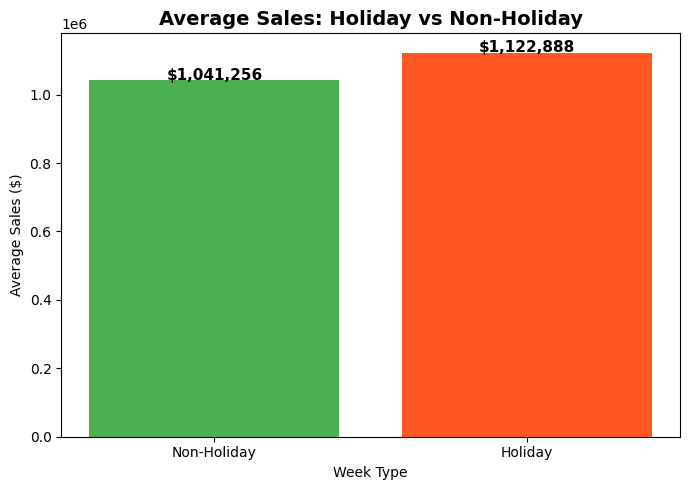

Chart saved!


In [9]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index()
holiday_sales['Holiday_Flag'] = holiday_sales['Holiday_Flag'].map({0: 'Non-Holiday', 1: 'Holiday'})

plt.figure(figsize=(7, 5))
bars = plt.bar(holiday_sales['Holiday_Flag'], holiday_sales['Weekly_Sales'],
               color=['#4CAF50', '#FF5722'])
plt.title('Average Sales: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
plt.xlabel('Week Type')
plt.ylabel('Average Sales ($)')

for bar, val in zip(bars, holiday_sales['Weekly_Sales']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\Sande\Desktop\sales-trend-visualization\output\04_holiday_sales.png', dpi=150)
plt.show()
print("Chart saved!")

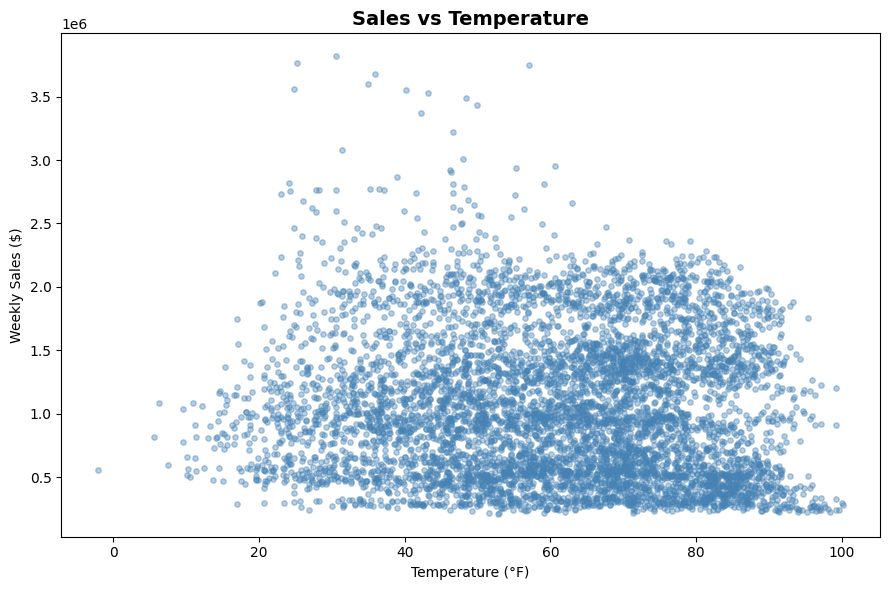

Chart saved!


In [10]:
plt.figure(figsize=(9, 6))
plt.scatter(df['Temperature'], df['Weekly_Sales'],
            color='steelblue', alpha=0.4, s=15)
plt.title('Sales vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°F)')
plt.ylabel('Weekly Sales ($)')
plt.tight_layout()
plt.savefig(r'C:\Users\Sande\Desktop\sales-trend-visualization\output\05_sales_vs_temperature.png', dpi=150)
plt.show()
print("Chart saved!")

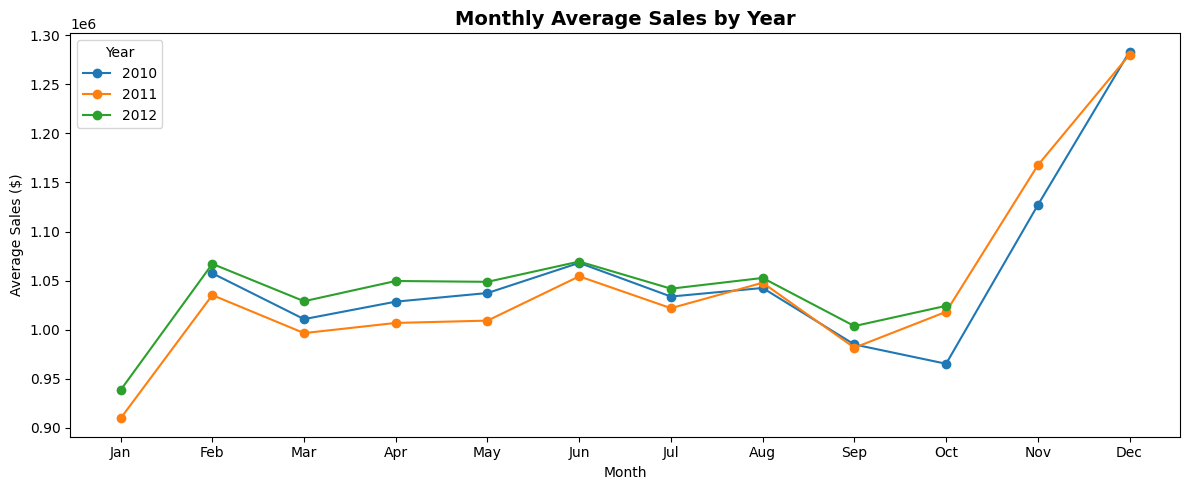

Chart saved!


In [11]:
monthly_avg = df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(12, 5))
for year in monthly_avg['Year'].unique():
    data = monthly_avg[monthly_avg['Year'] == year]
    plt.plot(data['Month'], data['Weekly_Sales'], marker='o', label=str(year))

plt.title('Monthly Average Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sales ($)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.savefig(r'C:\Users\Sande\Desktop\sales-trend-visualization\output\06_monthly_avg_by_year.png', dpi=150)
plt.show()
print("Chart saved!")

In [12]:
print("=" * 50)
print("   WALMART SALES ANALYSIS - KEY INSIGHTS")
print("=" * 50)

print(f"\n📦 Total Records      : {df.shape[0]:,}")
print(f"🏪 Total Stores       : {df['Store'].nunique()}")
print(f"💰 Total Sales        : ${df['Weekly_Sales'].sum():,.2f}")
print(f"📈 Avg Weekly Sales   : ${df['Weekly_Sales'].mean():,.2f}")
print(f"🏆 Best Store         : Store {df.groupby('Store')['Weekly_Sales'].sum().idxmax()}")
print(f"📅 Date Range         : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🎄 Holiday Weeks      : {df[df['Holiday_Flag']==1].shape[0]}")
print(f"📊 Non-Holiday Weeks  : {df[df['Holiday_Flag']==0].shape[0]}")

print("\n✅ All 6 charts saved to output folder!")
print("🎯 Project Complete!")

   WALMART SALES ANALYSIS - KEY INSIGHTS

📦 Total Records      : 6,435
🏪 Total Stores       : 45
💰 Total Sales        : $6,737,218,987.11
📈 Avg Weekly Sales   : $1,046,964.88
🏆 Best Store         : Store 20
📅 Date Range         : 2010-02-05 to 2012-10-26
🎄 Holiday Weeks      : 450
📊 Non-Holiday Weeks  : 5985

✅ All 6 charts saved to output folder!
🎯 Project Complete!
